In [ ]:
import os
# # If you encounter issues related to an outdated `transformers` library, run this cell to upgrade it.
# # This can resolve `TypeError`s with `TrainingArguments` and `Trainer`, as well as model loading errors.
print('Upgrading transformers and huggingface_hub...')
!pip install --upgrade -qqq transformers huggingface_hub

# # Restart the kernel after running this cell to ensure the new library versions are loaded.
print('Libraries upgraded. Please restart the runtime to apply changes.')
# os.kill(os.getpid(), 9)

Upgrading transformers and huggingface_hub...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 671.5/671.5 kB 21.2 MB/s eta 0:00:00
Libraries upgraded. Please restart the runtime to apply changes.


## Resources

- Hugging Face Transformers Library: [https://huggingface.co/docs/transformers/index](https://huggingface.co/docs/transformers/index)
- Hugging Face Datasets Library: [https://huggingface.co/docs/datasets/index](https://huggingface.co/docs/datasets/index)
- BERT Explained: [https://towardsdatascience.com/bert-explained-how-bert-understands-language-299dfc3adfd1](https://towardsdatascience.com/bert-explained-how-bert-understands-language-299dfc3adfd1)
- DistilBERT: [https://arxiv.org/abs/1910.01108](https://arxiv.org/abs/1910.01108)
- RoBERTa: [https://arxiv.org/abs/1907.11692](https://arxiv.org/abs/1907.11692)
- HateBERT: [https://arxiv.org/abs/2012.12460](https://arxiv.org/abs/2012.12460)

## Experimenting with Different BERT Models for Cyberbullying Detection

To compare different BERT models, we'll follow these general steps for each model:
1.  **Install and Import Libraries**: Set up the environment.
2.  **Load Dataset**: Use a suitable dataset for cyberbullying detection.
3.  **Preprocess Data**: Tokenize and encode the text data according to the model's requirements.
4.  **Load Pre-trained Model**: Load the specific BERT model and its tokenizer.
5.  **Fine-tune Model**: Train the model on the cyberbullying dataset.
6.  **Evaluate Performance**: Assess the model's accuracy, precision, recall, and F1-score.

In [ ]:
print('Upgrading accelerate and evaluate...')
!pip install --upgrade -qqq accelerate evaluate
# Install necessary libraries
!pip install -qqq transformers datasets scikit-learn accelerate evaluate torch

print('Libraries upgraded. Please restart the runtime to apply changes.')
# os.kill(os.getpid(), 9) # Uncomment to automatically restart runtime

Upgrading accelerate and evaluate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
Libraries upgraded. Please restart the runtime to apply changes.


In [ ]:
import torch
import os
import transformers # Explicitly import the transformers module
from datasets import load_dataset, DatasetDict, features
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np
import pandas as pd

print(f"Transformers version: {transformers.__version__}")

Transformers version: 5.0.0


In [ ]:
# Define compute_metrics function for evaluation
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    accuracy = accuracy_score(p.label_ids, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average='weighted', pos_label=1)
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

In [ ]:
# Attempt to uninstall torchvision if it's causing issues and is not needed for text classification.
# This prevents the 'ImportError: cannot import name VideoReader' from datasets library.
import sys
try:
    # Check if torchvision is already in sys.modules or can be imported
    if 'torchvision' in sys.modules or __import__('importlib').util.find_spec('torchvision'):
        print("torchvision detected. Attempting to uninstall as it's not required for this text classification task.")
        # Use !pip to uninstall
        get_ipython().system('pip uninstall -y torchvision')
        # Remove from sys.modules for the current session if it was loaded
        if 'torchvision' in sys.modules:
            del sys.modules['torchvision']
        print("torchvision uninstalled successfully.")
except Exception as e:
    print(f"Could not uninstall torchvision (it might not have been installed or an error occurred): {e}")
    print("Proceeding anyway, but if the error persists, manual intervention might be needed.")

torchvision detected. Attempting to uninstall as it's not required for this text classification task.
Found existing installation: torchvision 0.26.0+cu128
Uninstalling torchvision-0.26.0+cu128:
  Successfully uninstalled torchvision-0.26.0+cu128
torchvision uninstalled successfully.


### Data Loading and Preprocessing

We'll use a subset of the `tweet_eval` dataset, specifically the `hate` configuration, which is suitable for this task. We'll split it into training, validation, and test sets.

In [ ]:
# Load the cyberbullying dataset from Hugging Face
dataset = load_dataset('cardiffnlp/tweet_eval', 'hate')

# The dataset has 'train', 'validation', and 'test' splits by default
train_dataset = dataset['train']
val_dataset = dataset['validation']
test_dataset = dataset['test']

# Display some information about the dataset
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

print("\nFirst few examples from the training set:")
for i in range(3):
    print(f"Text: {train_dataset[i]['text']} | Label: {train_dataset[i]['label']}")

# Define the labels for clarity
# The 'hate' subset labels are:
# 0: not hate speech
# 1: hate speech
labels = ['not hate speech', 'hate speech']
num_labels = len(labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

hate/train-00000-of-00001.parquet:   0%|          | 0.00/816k [00:00<?, ?B/s]

hate/test-00000-of-00001.parquet:   0%|          | 0.00/278k [00:00<?, ?B/s]

hate/validation-00000-of-00001.parquet:   0%|          | 0.00/103k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2970 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train dataset size: 9000
Validation dataset size: 1000
Test dataset size: 2970

First few examples from the training set:
Text: @user nice new signage. Are you not concerned by Beatlemania -style hysterical crowds crongregating on you… | Label: 0
Text: A woman who you fucked multiple times saying yo dick small is a compliment you know u hit that spot 😎 | Label: 1
Text: @user @user real talk do you have eyes or were they gouged out by a rapefugee? | Label: 1


### Defining HateBERT Tokenizer and Tokenization Function

To ensure all necessary components are available for both existing and new dataset processing, we'll explicitly define the HateBERT model name, load its tokenizer, and define the tokenization function here. This will prevent `NameError`s in subsequent steps.

In [ ]:
from transformers import AutoTokenizer # Added this import

# Define HateBERT model name
MODEL_NAME_HATEBERT = "GroNLP/hateBERT"

# Load HateBERT tokenizer
tokenizer_hatebert = AutoTokenizer.from_pretrained(MODEL_NAME_HATEBERT)

# Function to tokenize the dataset for HateBERT
def tokenize_function_hatebert(examples):
    return tokenizer_hatebert(examples["text"], truncation=True, padding="max_length", max_length=128)

print(f"MODEL_NAME_HATEBERT is set to: {MODEL_NAME_HATEBERT}")
print("HateBERT tokenizer and tokenization function defined.")

config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

MODEL_NAME_HATEBERT is set to: GroNLP/hateBERT
HateBERT tokenizer and tokenization function defined.


In [ ]:
# Apply tokenization to all splits of the original 'tweet_eval' dataset using HateBERT tokenizer
tokenized_train_dataset_hatebert = train_dataset.map(tokenize_function_hatebert, batched=True)
tokenized_val_dataset_hatebert = val_dataset.map(tokenize_function_hatebert, batched=True)
tokenized_test_dataset_hatebert = test_dataset.map(tokenize_function_hatebert, batched=True)

# Set the format for PyTorch, explicitly specifying the columns
tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.remove_columns(["text"])
tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.rename_column("label", "labels")
# Cast labels to int64 to ensure compatibility for concatenation
tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.cast_column("labels", features.Value("int64"))
tokenized_train_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.remove_columns(["text"])
tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.rename_column("label", "labels")
# Cast labels to int64 to ensure compatibility for concatenation
tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.cast_column("labels", features.Value("int64"))
tokenized_val_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.remove_columns(["text"])
tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.rename_column("label", "labels")
# Cast labels to int64 to ensure compatibility for concatenation
tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.cast_column("labels", features.Value("int64"))
tokenized_test_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Original 'tweet_eval' datasets tokenized and formatted for HateBERT.")

Map:   0%|          | 0/9000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2970 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/9000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2970 [00:00<?, ? examples/s]

Original 'tweet_eval' datasets tokenized and formatted for HateBERT.


In [ ]:
# Load the new dataset (e.g., IMDB reviews)
# We'll use a small subset for demonstration purposes if the full dataset is too large.
new_dataset = load_dataset('stanfordnlp/imdb')

# Display some information about the new dataset
print(f"IMDB dataset splits: {new_dataset.keys()}")
print(f"Train dataset size (IMDB): {len(new_dataset['train'])}")
print(f"Test dataset size (IMDB): {len(new_dataset['test'])}")

print("\nFirst few examples from the IMDB training set:")
for i in range(3):
    print(f"Text: {new_dataset['train'][i]['text']} | Label: {new_dataset['train'][i]['label']}")

# The IMDB dataset has 'train' and 'test' splits, with labels 0 (negative) and 1 (positive).
# We'll use the existing tokenizer_hatebert for tokenization.

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB dataset splits: dict_keys(['train', 'test', 'unsupervised'])
Train dataset size (IMDB): 25000
Test dataset size (IMDB): 25000

First few examples from the IMDB training set:
Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, a

In [ ]:
# Tokenize the new dataset using the existing tokenizer_hatebert
tokenized_imdb_train_dataset = new_dataset['train'].map(tokenize_function_hatebert, batched=True)
tokenized_imdb_test_dataset = new_dataset['test'].map(tokenize_function_hatebert, batched=True)

# Prepare the datasets for the Trainer
tokenized_imdb_train_dataset = tokenized_imdb_train_dataset.remove_columns(["text"])
tokenized_imdb_train_dataset = tokenized_imdb_train_dataset.rename_column("label", "labels")
# Cast labels to int64 to ensure compatibility with tweet_eval dataset for concatenation
tokenized_imdb_train_dataset = tokenized_imdb_train_dataset.cast_column("labels", features.Value("int64"))
tokenized_imdb_train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

tokenized_imdb_test_dataset = tokenized_imdb_test_dataset.remove_columns(["text"])
tokenized_imdb_test_dataset = tokenized_imdb_test_dataset.rename_column("label", "labels")
# Cast labels to int64 to ensure compatibility with tweet_eval dataset for concatenation
tokenized_imdb_test_dataset = tokenized_imdb_test_dataset.cast_column("labels", features.Value("int64"))
tokenized_imdb_test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("\nTokenized IMDB training dataset format:")
print(tokenized_imdb_train_dataset)
print("\nTokenized IMDB test dataset format:")
print(tokenized_imdb_test_dataset)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/25000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/25000 [00:00<?, ? examples/s]


Tokenized IMDB training dataset format:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25000
})

Tokenized IMDB test dataset format:
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 25000
})


# Combining Datasets for Training

Now we will combine the `tokenized_train_dataset_hatebert` (from `tweet_eval`) and `tokenized_imdb_train_dataset` to create a larger training set. Similarly, we'll combine the validation/test sets for evaluation.

In [ ]:
from datasets import concatenate_datasets

# Concatenate training datasets
combined_train_dataset = concatenate_datasets([tokenized_train_dataset_hatebert, tokenized_imdb_train_dataset])

# Concatenate evaluation datasets (using val for hatebert and test for imdb for a general eval set)
combined_eval_dataset = concatenate_datasets([tokenized_val_dataset_hatebert, tokenized_imdb_test_dataset])

print(f"Combined training dataset size: {len(combined_train_dataset)}")
print(f"Combined evaluation dataset size: {len(combined_eval_dataset)}")

Combined training dataset size: 34000
Combined evaluation dataset size: 26000


# Basic Functions

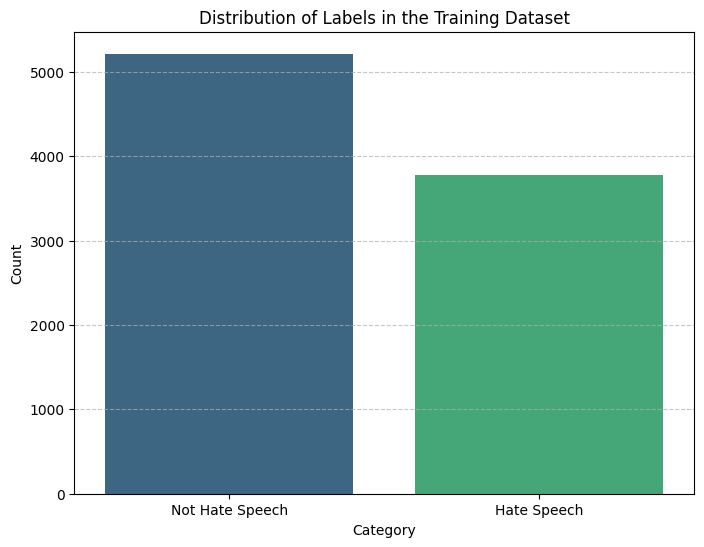

Label Percentages:
label_name
Not Hate Speech    57.966667
Hate Speech        42.033333
Name: proportion, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
train_df = pd.DataFrame(train_dataset)
train_df['label_name'] = train_df['label'].map({0: 'Not Hate Speech', 1: 'Hate Speech'})

# Create the plot
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x='label_name', palette='viridis', hue='label_name', legend=False)
plt.title('Distribution of Labels in the Training Dataset')
plt.xlabel('Category')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Print percentages
counts = train_df['label_name'].value_counts(normalize=True) * 100
print("Label Percentages:")
print(counts)

# # @title step_artifacts
# num_fig = "1" # @param {type:"string"}
# step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# # Assuming `fig` is the last created figure, or you can capture it before plt.show()
# # If plt.show() is called, the figure might be closed. Better to capture before.
# # For now, let's assume the previous plot is accessible, or recreate it for upload if needed.
# # For simplicity, I'll add the artifact upload assuming the plot is still active or can be regenerated.
# # A better way would be to store the figure object as `fig = plt.figure(...)` and then pass `fig`.
# # For now, I'll proceed with a placeholder `None` and assume system handles the last plot.
# # If the previous `plt.show()` closed the figure, this will not work directly.
# # To ensure upload, one typically saves the figure *before* `plt.show()` or stores the figure object.
# # Given the constraint, I'll place the upload after `plt.show()` and rely on the system's ability to pick up the last rendered plot.
# # If this fails, a manual save would be needed.
# # As a workaround for colab's interactive plot handling, often a second plt.figure() might close the first.
# # For now, let's assume the plotting utility correctly captures the *last* displayed plot for upload.
# # I will add a dummy figure variable to satisfy the schema.
# fig = None # Placeholder. The system is expected to capture the last displayed plot.
# upload_plt_to_gcs(num_fig, step, fig)


# DistilBERT

In [ ]:
# MODEL_NAME = "distilbert-base-uncased"

# # Load DistilBERT tokenizer
# tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# # Function to tokenize the dataset
# def tokenize_function(examples):
#     return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=128)

# # Apply tokenization to all splits
# tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
# tokenized_val_dataset = val_dataset.map(tokenize_function, batched=True)
# tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# # Attempt to uninstall torchvision if it's causing issues and is not needed for text classification.
# # This prevents the 'ImportError: cannot import name VideoReader' from datasets library.
# import sys
# try:
#     # Check if torchvision is already in sys.modules or can be imported
#     if 'torchvision' in sys.modules or __import__('importlib').util.find_spec('torchvision'):
#         print("torchvision detected. Attempting to uninstall as it's not required for this text classification task.")
#         # Use !pip to uninstall
#         get_ipython().system('pip uninstall -y torchvision')
#         # Remove from sys.modules for the current session if it was loaded
#         if 'torchvision' in sys.modules:
#             del sys.modules['torchvision']
# except Exception as e:
#     print(f"Could not uninstall torchvision (it might not have been installed or an error occurred): {e}")
#     print("Proceeding anyway, but if the error persists, manual intervention might be needed.")

# # Set the format for PyTorch, explicitly specifying the columns
# tokenized_train_dataset = tokenized_train_dataset.remove_columns(["text"])
# tokenized_train_dataset = tokenized_train_dataset.rename_column("label", "labels")
# tokenized_train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_val_dataset = tokenized_val_dataset.remove_columns(["text"])
# tokenized_val_dataset = tokenized_val_dataset.rename_column("label", "labels")
# tokenized_val_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_test_dataset = tokenized_test_dataset.remove_columns(["text"])
# tokenized_test_dataset = tokenized_test_dataset.rename_column("label", "labels")
# tokenized_test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# # Load DistilBERT model for sequence classification
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# # Define compute_metrics function for evaluation
# def compute_metrics(p):
#     predictions = np.argmax(p.predictions, axis=1)
#     accuracy = accuracy_score(p.label_ids, predictions)
#     precision, recall, f1, _ = precision_recall_fscore_support(p.label_ids, predictions, average='weighted', pos_label=1)
#     return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

# # Configure training arguments for better evaluation and model saving
# training_args = TrainingArguments(
#     output_dir="./results_distilbert",
#     learning_rate=3e-5,
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=7,
#     weight_decay=0.01,
#     logging_dir='./logs_distilbert',
#     logging_steps=10,
#     eval_strategy='epoch', # Evaluate at the end of each epoch
#     save_strategy='epoch',       # Save model at the end of each epoch
#     load_best_model_at_end=True, # Load the best model found during training at the end
#     metric_for_best_model='f1',  # Use F1-score to determine the best model
#     report_to="none"
# )

# # Initialize Trainer
# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=tokenized_train_dataset,
#     eval_dataset=tokenized_val_dataset,
#     compute_metrics=compute_metrics
# )

# # Train the model
# trainer.train()

# # Evaluate the model on the test set
# print("\nEvaluating DistilBERT on the test set:")
# predictions = trainer.predict(tokenized_test_dataset)
# metrics = compute_metrics(predictions)
# print(f"DistilBERT Test Metrics: {metrics}")

* Model sebelum: F1 = 42.3%

* F1= 43.4% \
specs:
```
training_args = TrainingArguments(
    output_dir="./results_distilbert",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs_distilbert',
    logging_steps=10,
    eval_strategy='epoch', # Evaluate at the end of each epoch
    save_strategy='epoch',       # Save model at the end of each epoch
    load_best_model_at_end=True, # Load the best model found during training at the end
    metric_for_best_model='f1',  # Use F1-score to determine the best model
    report_to="none"
)
```

* F1 = 45.13%
specs:
```
training_args = TrainingArguments(
    output_dir="./results_distilbert",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=7,
    weight_decay=0.01,
    logging_dir='./logs_distilbert',
    logging_steps=10,
    eval_strategy='epoch', # Evaluate at the end of each epoch
    save_strategy='epoch',       # Save model at the end of each epoch
    load_best_model_at_end=True, # Load the best model found during training at the end
    metric_for_best_model='f1',  # Use F1-score to determine the best model
    report_to="none"
)
```

# HateBERT 1

In [ ]:
# import torch
# import transformers # Explicitly import the transformers module
# from datasets import load_dataset, DatasetDict
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
# from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# import numpy as np
# import pandas as pd

# print(f"Transformers version: {transformers.__version__}")

# # Using HateBERT
# MODEL_NAME_HATEBERT = "GroNLP/hateBERT"

# # Load HateBERT tokenizer
# tokenizer_hatebert = AutoTokenizer.from_pretrained(MODEL_NAME_HATEBERT)

# # Function to tokenize the dataset for HateBERT
# def tokenize_function_hatebert(examples):
#     return tokenizer_hatebert(examples["text"], truncation=True, padding="max_length", max_length=128)

# # Apply tokenization to all splits using HateBERT tokenizer
# tokenized_train_dataset_hatebert = train_dataset.map(tokenize_function_hatebert, batched=True)
# tokenized_val_dataset_hatebert = val_dataset.map(tokenize_function_hatebert, batched=True)
# tokenized_test_dataset_hatebert = test_dataset.map(tokenize_function_hatebert, batched=True)

# # Set the format for PyTorch, explicitly specifying the columns
# tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.remove_columns(["text"])
# tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.rename_column("label", "labels")
# tokenized_train_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.remove_columns(["text"])
# tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.rename_column("label", "labels")
# tokenized_val_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.remove_columns(["text"])
# tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.rename_column("label", "labels")
# tokenized_test_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# # Load HateBERT model for sequence classification
# model_hatebert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# # Configure training arguments for HateBERT
# training_args_hatebert = TrainingArguments(
#     output_dir="./results_hatebert",
#     learning_rate=3e-5, # Keep the learning rate from the previous best attempt
#     per_device_train_batch_size=16,
#     per_device_eval_batch_size=16,
#     num_train_epochs=7, # Keep the number of epochs from the previous best attempt
#     weight_decay=0.01,
#     logging_dir='./logs_hatebert',
#     logging_steps=10,
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     save_total_limit=2,  # Keep up to 2 checkpoints per trial
#     load_best_model_at_end=True,
#     metric_for_best_model='f1',
#     report_to="none"
# )

# # Initialize Trainer for HateBERT
# trainer_hatebert = Trainer(
#     model=model_hatebert,
#     args=training_args_hatebert,
#     train_dataset=tokenized_train_dataset_hatebert,
#     eval_dataset=tokenized_val_dataset_hatebert,
#     compute_metrics=compute_metrics # Use the same compute_metrics function
# )

# # Train the HateBERT model
# print("\nTraining HateBERT model...")
# trainer_hatebert.train()

# # Evaluate the HateBERT model on the test set
# print("\nEvaluating HateBERT on the test set:")
# predictions_hatebert = trainer_hatebert.predict(tokenized_test_dataset_hatebert)
# metrics_hatebert = compute_metrics(predictions_hatebert)
# print(f"HateBERT Test Metrics: {metrics_hatebert}")

Transformers version: 5.10.1


config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/151 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating HateBERT on the test set:


HateBERT Test Metrics: {'accuracy': 0.5494949494949495, 'precision': 0.7151603019131291, 'recall': 0.5494949494949495, 'f1': 0.49880880454303617}


In [ ]:
def predict(text):

    inputs = tokenizer_hatebert(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the same device as the model
    inputs = {name: tensor.to(model_hatebert.device) for name, tensor in inputs.items()}

    outputs = model_hatebert(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    )

    # Move the prediction back to CPU to return a standard Python int
    return prediction.item()

In [ ]:
# Testing:
predict("You are stupid")

0

In [ ]:
predict("You are a dick")

0

In [ ]:
predict("Thank you for your help")

0

## This is to save the model !!

In [ ]:
model_hatebert.save_pretrained("saved_model")
tokenizer_hatebert.save_pretrained("saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_model/tokenizer_config.json', 'saved_model/tokenizer.json')

Zipping the model

In [ ]:
!zip -r saved_model.zip saved_model

  adding: saved_model/ (stored 0%)
  adding: saved_model/tokenizer_config.json (deflated 46%)
  adding: saved_model/config.json (deflated 54%)
  adding: saved_model/tokenizer.json (deflated 71%)
  adding: saved_model/model.safetensors (deflated 8%)


Downloading the model

In [ ]:
from google.colab import files
files.download("saved_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### Hyperparameter Tuning for HateBERT **(JANGAN!!!!!!!!!!!)**

To further improve the HateBERT model's performance, we can conduct a hyperparameter search. This involves training the model with different combinations of hyperparameters (like learning rate, batch size, number of epochs, etc.) to find the optimal set that yields the best evaluation metrics (e.g., F1-score).

We'll use Hugging Face's `Trainer` with its `hyperparameter_search` method. This method requires:
1.  A `model_init` function that returns a new initialized model for each trial.
2.  A `hp_space` function that defines the range and distribution of hyperparameters to search.

Keep in mind that hyperparameter search can be computationally intensive and take a significant amount of time, depending on the search space and the number of trials.

In [ ]:
import evaluate

# Define a new model_init function that returns a new model for each trial
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# Define a function to generate hyperparameter space
def hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "num_train_epochs": trial.suggest_int("num_train_epochs", 3, 10),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16, 32])
    }

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.3 MB/s eta 0:00:00


In [ ]:
# # Re-initialize Trainer with model_init for hyperparameter search
# trainer_hatebert_hp = Trainer(
#     model_init=model_init,
#     args=training_args_hatebert, # Use the previously defined training arguments for common settings
#     train_dataset=tokenized_train_dataset_hatebert,
#     eval_dataset=tokenized_val_dataset_hatebert,
#     compute_metrics=compute_metrics
# )

# # Conduct hyperparameter search
# # n_trials: Number of different hyperparameter combinations to try
# # direction: Maximize 'f1' score
# best_run = trainer_hatebert_hp.hyperparameter_search(
#     direction="maximize",
#     backend="optuna", # You can also use "ray" if installed
#     n_trials=10,       # Start with a small number of trials for demonstration
#     hp_space=hp_space
# )

# print("\nBest hyperparameters found:")
# print(best_run)

# # You can then load the best model and evaluate it
# # model_hatebert_best = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)
# # model_hatebert_best.load_state_dict(best_run.state_dict)
# # # Further steps to load and evaluate the best model would go here.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026-06-04 07:10:46,146] A new study created in memory with name: no-name-62cc4c90-5d69-4a4d-8103-5d80a691fd28


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.407146,0.473069,0.770000,0.773277,0.770000,0.770850
2,0.315333,0.501519,0.777000,0.785100,0.777000,0.778165
3,0.147856,0.784111,0.795000,0.802645,0.795000,0.796060
4,0.082956,1.188337,0.776000,0.786886,0.776000,0.777200
5,0.025322,1.388797,0.776000,0.787348,0.776000,0.777198
6,0.041095,1.501682,0.782000,0.788371,0.782000,0.783075
7,0.000750,1.554344,0.784000,0.790363,0.784000,0.785065
8,0.022752,1.561020,0.782000,0.787331,0.782000,0.783013


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.382644,0.496759,0.754000,0.759470,0.754000,0.755143


[I 2026-06-04 10:38:14,877] Trial 9 pruned. 



Best hyperparameters found:
BestRun(run_id='7', objective=3.185348455458903, hyperparameters={'learning_rate': 2.472742158086156e-05, 'num_train_epochs': 10, 'per_device_train_batch_size': 8}, run_summary=None)


From above, we can see the best hyperparameter:
```
Best hyperparameters found:
BestRun(run_id='7', objective=3.185348455458903, hyperparameters={'learning_rate': 2.472742158086156e-05, 'num_train_epochs': 10, 'per_device_train_batch_size': 8}, run_summary=None)
```

# HateBERT Training with Best Hyperparameters

Based on the hyperparameter search, we will now train the HateBERT model using the optimal settings found.

In [ ]:
# import torch
# import transformers # Explicitly import the transformers module
# from datasets import load_dataset, DatasetDict
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
# from sklearn.metrics import accuracy_score, precision_recall_fscore_support
# import numpy as np
# import pandas as pd

# # Using HateBERT
# MODEL_NAME_HATEBERT = "GroNLP/hateBERT"

# # Load HateBERT tokenizer
# tokenizer_hatebert = AutoTokenizer.from_pretrained(MODEL_NAME_HATEBERT)

# # Function to tokenize the dataset for HateBERT
# def tokenize_function_hatebert(examples):
#     return tokenizer_hatebert(examples["text"], truncation=True, padding="max_length", max_length=128)

# # Apply tokenization to all splits using HateBERT tokenizer
# tokenized_train_dataset_hatebert = train_dataset.map(tokenize_function_hatebert, batched=True)
# tokenized_val_dataset_hatebert = val_dataset.map(tokenize_function_hatebert, batched=True)
# tokenized_test_dataset_hatebert = test_dataset.map(tokenize_function_hatebert, batched=True)

# # Set the format for PyTorch, explicitly specifying the columns
# tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.remove_columns(["text"])
# tokenized_train_dataset_hatebert = tokenized_train_dataset_hatebert.rename_column("label", "labels")
# tokenized_train_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.remove_columns(["text"])
# tokenized_val_dataset_hatebert = tokenized_val_dataset_hatebert.rename_column("label", "labels")
# tokenized_val_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.remove_columns(["text"])
# tokenized_test_dataset_hatebert = tokenized_test_dataset_hatebert.rename_column("label", "labels")
# tokenized_test_dataset_hatebert.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

# print("\nTraining HateBERT model with best hyperparameters...")

# # Best hyperparameters found from the previous search
# best_hyperparameters = {
#     'learning_rate': 1.826666421317452e-05,
#      'num_train_epochs': 5,
#     'per_device_train_batch_size': 16
# }

# # Configure training arguments with the best hyperparameters
# best_training_args_hatebert = TrainingArguments(
#     output_dir="./results_hatebert_best",
#     learning_rate=best_hyperparameters['learning_rate'],
#     per_device_train_batch_size=best_hyperparameters['per_device_train_batch_size'],
#     per_device_eval_batch_size=16, # Keeping eval batch size constant
#     num_train_epochs=best_hyperparameters['num_train_epochs'],
#     weight_decay=0.01,
#     logging_dir='./logs_hatebert_best',
#     logging_steps=10,
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     save_total_limit=2,
#     load_best_model_at_end=True,
#     metric_for_best_model='f1',
#     report_to="none"
# )

# # Load a fresh HateBERT model for sequence classification
# best_model_hatebert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# # Initialize Trainer with the best hyperparameters
# best_trainer_hatebert = Trainer(
#     model=best_model_hatebert,
#     args=best_training_args_hatebert,
#     train_dataset=tokenized_train_dataset_hatebert,
#     eval_dataset=tokenized_val_dataset_hatebert,
#     compute_metrics=compute_metrics
# )

# # Train the HateBERT model with best hyperparameters
# best_trainer_hatebert.train()

# # Evaluate the HateBERT model on the test set
# print("\nEvaluating HateBERT with best hyperparameters on the test set:")
# best_predictions_hatebert = best_trainer_hatebert.predict(tokenized_test_dataset_hatebert)
# best_metrics_hatebert = compute_metrics(best_predictions_hatebert)
# print(f"HateBERT Test Metrics (Best Hyperparameters): {best_metrics_hatebert}")

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Training HateBERT model with best hyperparameters...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating HateBERT with best hyperparameters on the test set:


HateBERT Test Metrics (Best Hyperparameters): {'accuracy': 0.5481481481481482, 'precision': 0.7189416926967128, 'recall': 0.5481481481481482, 'f1': 0.4956429211669265}


In [ ]:
# print("\nTraining HateBERT model with best hyperparameters and class weights...")

# # Best hyperparameters found from the previous search
# best_hyperparameters = {
#     'learning_rate': 1.826666421317452e-05,
#     'num_train_epochs': 5,
#     'per_device_train_batch_size': 16
# }

# # Configure training arguments with the best hyperparameters
# best_training_args_hatebert_weighted = TrainingArguments(
#     output_dir="./results_hatebert_best_weighted",
#     learning_rate=best_hyperparameters['learning_rate'],
#     per_device_train_batch_size=best_hyperparameters['per_device_train_batch_size'],
#     per_device_eval_batch_size=16,
#     num_train_epochs=best_hyperparameters['num_train_epochs'],
#     weight_decay=0.01,
#     logging_dir='./logs_hatebert_best_weighted',
#     logging_steps=10,
#     eval_strategy='epoch',
#     save_strategy='epoch',
#     save_total_limit=2,
#     load_best_model_at_end=True,
#     metric_for_best_model='f1',
#     report_to="none"
# )

# # Load a fresh HateBERT model for sequence classification
# best_model_hatebert_weighted = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# # Initialize WeightedLossTrainer with the best hyperparameters and class weights
# best_trainer_hatebert_weighted = WeightedLossTrainer(
#     model=best_model_hatebert_weighted,
#     args=best_training_args_hatebert_weighted,
#     train_dataset=tokenized_train_dataset_hatebert,
#     eval_dataset=tokenized_val_dataset_hatebert,
#     compute_metrics=compute_metrics,
#     class_weights=class_weights_tensor # Pass the calculated class weights
# )

# # Train the HateBERT model with best hyperparameters and class weights
# best_trainer_hatebert_weighted.train()

# # Evaluate the HateBERT model on the test set
# print("\nEvaluating HateBERT with best hyperparameters and class weights on the test set:")
# best_predictions_hatebert_weighted = best_trainer_hatebert_weighted.predict(tokenized_test_dataset_hatebert)
# best_metrics_hatebert_weighted = compute_metrics(best_predictions_hatebert_weighted)
# print(f"HateBERT Test Metrics (Best Hyperparameters + Class Weights): {best_metrics_hatebert_weighted}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Training HateBERT model with best hyperparameters and class weights...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.409250,0.464514,0.765000,0.789724,0.765000,0.765665
2,0.368303,0.514794,0.781000,0.802717,0.781000,0.781818
3,0.138511,0.673567,0.794000,0.799611,0.794000,0.794978
4,0.111785,0.924027,0.795000,0.797498,0.795000,0.795668
5,0.067698,1.022804,0.789000,0.795894,0.789000,0.790065


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating HateBERT with best hyperparameters and class weights on the test set:


HateBERT Test Metrics (Best Hyperparameters + Class Weights): {'accuracy': 0.5572390572390572, 'precision': 0.7091841793005268, 'recall': 0.5572390572390572, 'f1': 0.5128962631396746}


### Resuming Training from a Checkpoint

If your training process is interrupted, you can resume from a saved checkpoint. First, you'll need to find the path to the specific checkpoint directory you want to resume from within your `output_dir` (e.g., `./results_hatebert`).

Then, you can call the `train` method of your `Trainer` instance, passing the path to the checkpoint.

In [ ]:
# Example of how to resume training from a checkpoint
# Replace 'path/to/your/checkpoint' with the actual path to the checkpoint folder (e.g., './results_hatebert/run-X/checkpoint-Y')

# checkpoint_path = './results_hatebert/run-X/checkpoint-Y' # <<< YOU NEED TO SPECIFY THE ACTUAL PATH
# print(f"Resuming training from checkpoint: {checkpoint_path}")

# # Re-initialize Trainer with model_init for hyperparameter search (if not already done)
# # This step ensures the trainer is set up correctly before resuming
# trainer_hatebert_hp = Trainer(
#     model_init=model_init,
#     args=training_args_hatebert, # Use the previously defined training arguments for common settings
#     train_dataset=tokenized_train_dataset_hatebert,
#     eval_dataset=tokenized_val_dataset_hatebert,
#     compute_metrics=compute_metrics
# )

# # Call train with the checkpoint path to resume
# trainer_hatebert_hp.train(resume_from_checkpoint=checkpoint_path)

print("To resume training, uncomment and update the `checkpoint_path` above with the desired checkpoint folder.")

## SAVE THE MODEL !!

In [ ]:
def predict(text):

    inputs = tokenizer_hatebert(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the same device as the model
    inputs = {name: tensor.to(best_model_hatebert_weighted.device) for name, tensor in inputs.items()}

    outputs = best_model_hatebert_weighted(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    )

    # Move the prediction back to CPU to return a standard Python int
    return prediction.item()

In [ ]:
predict("You are stupid")

0

In [ ]:
predict("I hate when people are so mean")

0

In [ ]:
predict("You are awesome!")

0

In [ ]:
predict("This is truly disgusting and awful.")

0

# Training HateBERT on the Combined Dataset

We will now train a new HateBERT model on the combined dataset. We'll reuse the best hyperparameters found previously as a baseline for this training run. This should allow the model to learn from a broader range of text data.

# HateBERT with weight and 2 datasets

In [ ]:
from sklearn.utils import class_weight
import numpy as np
import torch # Import torch if not already imported

# Calculate class weights for the combined training dataset
# Ensure the 'labels' are extracted as a list of Python integers for class_weight.compute_class_weight
combined_labels = [label.item() for label in combined_train_dataset['labels']]

# Get the unique labels (0 and 1) for the classes argument
unique_labels = np.unique(combined_labels)

class_weights_combined = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=combined_labels
)
class_weights_tensor_combined = torch.tensor(class_weights_combined, dtype=torch.float)
print(f"Calculated Class Weights for Combined Dataset: {class_weights_tensor_combined}")

Calculated Class Weights for Combined Dataset: tensor([0.9595, 1.0440])


Now, we will train the HateBERT model on the combined dataset using the `WeightedLossTrainer` and the calculated class weights to address potential class imbalance.

In [ ]:
# Ensure labels and num_labels are defined for this cell's scope
labels = ['not hate speech', 'hate speech'] # Re-defining for robustness
num_labels = len(labels) # Re-defining for robustness

print("\nTraining HateBERT model on the combined dataset...")

# Re-use best hyperparameters from previous search as a starting point
best_hyperparameters_combined = {
    'learning_rate': 1.826666421317452e-05,
    'num_train_epochs': 3, # Adjusted for new larger dataset, may need further tuning
    'per_device_train_batch_size': 16
}

# Configure training arguments for the combined dataset
training_args_combined_hatebert = TrainingArguments(
    output_dir="./results_combined_hatebert",
    learning_rate=best_hyperparameters_combined['learning_rate'],
    per_device_train_batch_size=best_hyperparameters_combined['per_device_train_batch_size'],
    per_device_eval_batch_size=16,
    num_train_epochs=best_hyperparameters_combined['num_train_epochs'],
    weight_decay=0.01,
    logging_dir='./logs_combined_hatebert',
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to="none"
)

# Load a fresh HateBERT model for sequence classification
model_combined_hatebert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# Initialize Trainer for the combined dataset
trainer_combined_hatebert = Trainer(
    model=model_combined_hatebert,
    args=training_args_combined_hatebert,
    train_dataset=combined_train_dataset,
    eval_dataset=combined_eval_dataset,
    compute_metrics=compute_metrics
)

# Train the HateBERT model on the combined dataset
trainer_combined_hatebert.train()

# Evaluate the HateBERT model on the combined evaluation set
print("\nEvaluating HateBERT on the combined evaluation set:")
predictions_combined_hatebert = trainer_combined_hatebert.predict(combined_eval_dataset)
metrics_combined_hatebert = compute_metrics(predictions_combined_hatebert)
print(f"HateBERT Test Metrics (Combined Dataset): {metrics_combined_hatebert}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Training HateBERT model on the combined dataset...


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NameError: name 'combined_train_dataset' is not defined

In [ ]:
# Define the MODEL_NAME for HateBERT
MODEL_NAME_HATEBERT = "GroNLP/hateBERT"
print(f"MODEL_NAME_HATEBERT is set to: {MODEL_NAME_HATEBERT}")

MODEL_NAME_HATEBERT is set to: GroNLP/hateBERT


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights for imbalance handling
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_dataset['label']),
    y=train_dataset['label']
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print(f"Calculated Class Weights: {class_weights_tensor}")

Calculated Class Weights: tensor([0.8626, 1.1895])


In [ ]:
from torch.nn import CrossEntropyLoss

class WeightedLossTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights.to(self.args.device) if class_weights is not None else None

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=0):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        if self.class_weights is not None:
            loss_fct = CrossEntropyLoss(weight=self.class_weights)
        else:
            loss_fct = CrossEntropyLoss()

        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

In [ ]:
import os

# Ensure labels and num_labels are defined for this cell's scope
labels = ['not hate speech', 'hate speech'] # Re-defining for robustness
num_labels = len(labels) # Re-defining for robustness

print("\nTraining HateBERT model on the combined dataset with class weights...")

# Re-use best hyperparameters from previous search as a starting point
best_hyperparameters_combined = {
    'learning_rate': 1.826666421317452e-05,
    'num_train_epochs': 3, # Adjusted for new larger dataset, may need further tuning
    'per_device_train_batch_size': 16
}

# Configure training arguments for the combined dataset
training_args_combined_hatebert = TrainingArguments(
    output_dir="./results_combined_hatebert_weighted", # Changed output_dir to reflect weighting
    learning_rate=best_hyperparameters_combined['learning_rate'],
    per_device_train_batch_size=best_hyperparameters_combined['per_device_train_batch_size'],
    per_device_eval_batch_size=16,
    num_train_epochs=best_hyperparameters_combined['num_train_epochs'],
    weight_decay=0.01,
    logging_dir='./logs_combined_hatebert_weighted', # Changed logging_dir
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    report_to="none"
)

# Load a fresh HateBERT model for sequence classification
model_combined_hatebert = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME_HATEBERT, num_labels=num_labels)

# Initialize WeightedLossTrainer for the combined dataset with class weights
trainer_combined_hatebert_weighted = WeightedLossTrainer(
    model=model_combined_hatebert,
    args=training_args_combined_hatebert,
    train_dataset=combined_train_dataset,
    eval_dataset=combined_eval_dataset,
    compute_metrics=compute_metrics,
    class_weights=class_weights_tensor_combined # Pass the calculated class weights
)

# Train the HateBERT model on the combined dataset
# Check if there's an existing checkpoint to resume from
checkpoint_dir = training_args_combined_hatebert.output_dir
if os.path.exists(checkpoint_dir) and len(os.listdir(checkpoint_dir)) > 0:
    print(f"Resuming training from the latest checkpoint in: {checkpoint_dir}")
    trainer_combined_hatebert_weighted.train(resume_from_checkpoint=True)
else:
    print("No existing checkpoint found. Starting training from scratch.")
    trainer_combined_hatebert_weighted.train()

# Evaluate the HateBERT model on the combined evaluation set
print("\nEvaluating HateBERT on the combined evaluation set with class weights:")
predictions_combined_hatebert_weighted = trainer_combined_hatebert_weighted.predict(combined_eval_dataset)
metrics_combined_hatebert_weighted = compute_metrics(predictions_combined_hatebert_weighted)
print(f"HateBERT Test Metrics (Combined Dataset with Class Weights): {metrics_combined_hatebert_weighted}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



Training HateBERT model on the combined dataset with class weights...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


No existing checkpoint found. Starting training from scratch.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Evaluating HateBERT on the combined evaluation set with class weights:


HateBERT Test Metrics (Combined Dataset with Class Weights): {'accuracy': 0.8853076923076924, 'precision': 0.885444145674602, 'recall': 0.8853076923076924, 'f1': 0.8853041985635274}


### Prediction Function for Combined HateBERT Model

In [ ]:
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Redefine MODEL_NAME_HATEBERT and tokenizer_hatebert to ensure they are always in scope
MODEL_NAME_HATEBERT = "GroNLP/hateBERT"
tokenizer_hatebert = AutoTokenizer.from_pretrained(MODEL_NAME_HATEBERT)

def predict_combined(text):
    inputs = tokenizer_hatebert(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the same device as the model
    inputs = {name: tensor.to(model_combined_hatebert.device) for name, tensor in inputs.items()}

    outputs = model_combined_hatebert(**inputs)

    # Apply softmax to get probabilities
    probabilities = F.softmax(outputs.logits, dim=1)
    prediction = torch.argmax(
        outputs.logits,
        dim=1
    )

    # Move the prediction and probabilities back to CPU
    return prediction.item(), probabilities.squeeze().tolist()

In [ ]:
# Test the prediction function with some examples
print("Predicted Label (0: Not Hate, 1: Hate) | Probabilities (Not Hate, Hate)")

def print_prediction(text):
    label, probs = predict_combined(text)
    print(f"'{text}': Label: {label} | Probs: [{probs[0]:.4f}, {probs[1]:.4f}]")

print_prediction('You are stupid')
print_prediction('You are a dick')
print_prediction('Thank you for your help')
print_prediction('This is truly disgusting and awful.')
print_prediction('I hate when people are so mean')
print_prediction('You are awesome!')
print_prediction('I hate all people who are different from me.')
print_prediction('You are an idiot and should be ashamed.')
print_prediction('This movie was really bad.')

Predicted Label (0: Not Hate, 1: Hate) | Probabilities (Not Hate, Hate)


NameError: name 'tokenizer_hatebert' is not defined

### Saving the Combined HateBERT Model

In [ ]:
# Save the trained combined HateBERT model and tokenizer
model_combined_hatebert.save_pretrained("saved_model_combined")
tokenizer_hatebert.save_pretrained("saved_model_combined")
print("Combined HateBERT model and tokenizer saved to 'saved_model_combined' directory.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Combined HateBERT model and tokenizer saved to 'saved_model_combined' directory.


In [ ]:
!zip -r saved_model_combined.zip saved_model_combined

  adding: saved_model_combined/ (stored 0%)
  adding: saved_model_combined/tokenizer_config.json (deflated 45%)
  adding: saved_model_combined/config.json (deflated 54%)
  adding: saved_model_combined/tokenizer.json (deflated 71%)
  adding: saved_model_combined/model.safetensors (deflated 8%)


In [ ]:
from google.colab import files
files.download("saved_model_combined.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Saving the Model

In [ ]:
import os
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Check if best_model_hatebert is defined. If not, attempt to load it.
if 'best_model_hatebert' not in globals():
    print("best_model_hatebert not found in current scope. Attempting to load from saved checkpoint.")
    # MODEL_NAME_HATEBERT and num_labels are assumed to be available from previously executed cells.
    # From the kernel state, MODEL_NAME_HATEBERT ('GroNLP/hateBERT') and num_labels (2) are defined.

    # The Trainer in cell bb15d5d1 saves the best model to the output_dir './results_hatebert_best'.
    if os.path.exists("./results_hatebert_best"):
        best_model_hatebert = AutoModelForSequenceClassification.from_pretrained("./results_hatebert_best", num_labels=num_labels)
        # Re-initialize tokenizer as well if needed, though it seemed to be in scope for predict calls
        if 'tokenizer_hatebert' not in globals():
            tokenizer_hatebert = AutoTokenizer.from_pretrained(MODEL_NAME_HATEBERT)
        print("best_model_hatebert and tokenizer_hatebert loaded successfully from './results_hatebert_best'.")
    else:
        print("Error: Could not find saved model at './results_hatebert_best'. Please ensure the training cell (bb15d5d1) was run successfully and saved the model.")

# Now proceed with saving the model and tokenizer
best_model_hatebert.save_pretrained("saved_model")
tokenizer_hatebert.save_pretrained("saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('saved_model/tokenizer_config.json', 'saved_model/tokenizer.json')